# 04 Multimorbidity Patterns

## Purpose
Study common diseases, disease co-occurrence, and diagnosis trajectories over time.

## Imports

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables"
MODELS_DIR = PROJECT_ROOT / "models"
for directory in [FIGURES_DIR, TABLES_DIR, MODELS_DIR, DATA_DIR / "processed"]:
    directory.mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.data_cleaning import load_raw_data, clean_all, make_condition_events
from src.visualization import set_plot_style, save_fig, plot_condition_prevalence

set_plot_style()

## Data loading

In [2]:
data = clean_all(load_raw_data(DATA_DIR))
condition_events = make_condition_events(data["diagnoses"])
condition_events["year"] = condition_events["visit_date"].dt.year
condition_events.head()

,patient_id,visit_date,visit_type,condition,icd10,provider_specialty,diagnosis_position,year
0,P0000001,2018-07-26,telehealth,hyperlipidemia,E78.5,internal_medicine,primary,2018
1,P0000001,2018-07-26,telehealth,chronic_kidney_disease,N18.3,internal_medicine,secondary,2018
2,P0000001,2020-04-09,outpatient,hyperlipidemia,E78.5,nephrology,primary,2020
3,P0000001,2020-04-09,outpatient,chronic_kidney_disease,N18.3,nephrology,secondary,2020
4,P0000001,2020-04-09,outpatient,osteoarthritis,M19.90,nephrology,secondary,2020


## Main analysis

In [3]:
condition_prevalence = (
    condition_events.groupby("condition")
    .agg(events=("condition", "count"), patients=("patient_id", "nunique"))
    .sort_values("patients", ascending=False)
)
condition_prevalence.head(15)

,events,patients
condition,,
hypertension,108405,55875
obesity,95139,49313
hyperlipidemia,84628,44422
chronic_kidney_disease,45322,18636
osteoarthritis,26682,14561
type2_diabetes,27584,12969
anxiety,23002,12108
depression,18105,9988
asthma,16183,8916


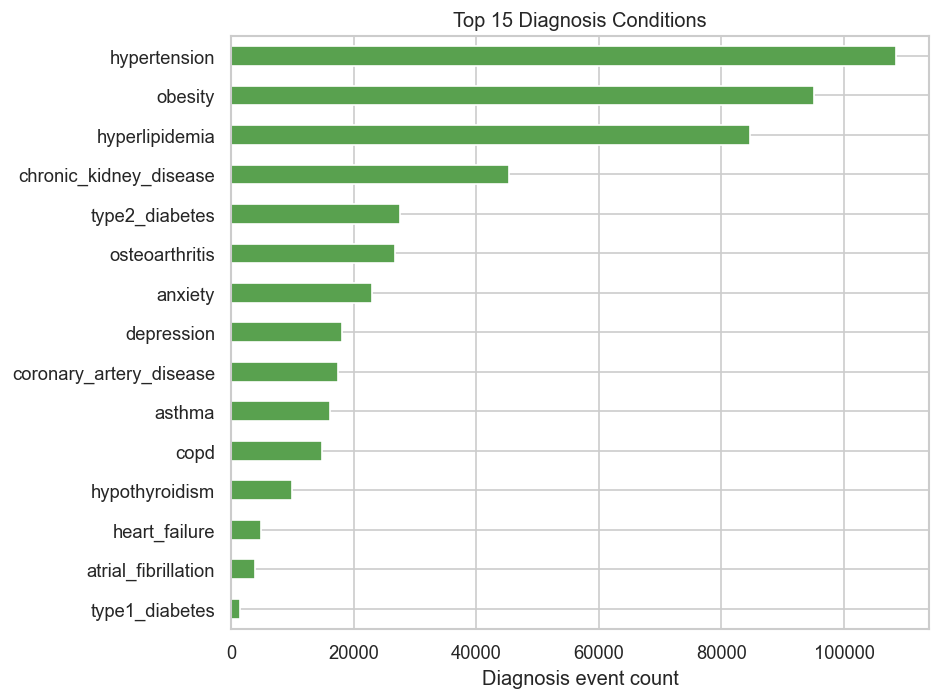

In [4]:
fig, ax = plot_condition_prevalence(condition_events, top_n=15, path=FIGURES_DIR / "04_top_conditions.png")

condition,anxiety,asthma,chronic_kidney_disease,copd,coronary_artery_disease,depression,hyperlipidemia,hypertension,hypothyroidism,obesity,osteoarthritis,type2_diabetes
condition,,,,,,,,,,,,
anxiety,12108,722,1732,619,753,797,3659,4743,434,4123,1123,1073
asthma,722,8916,1736,620,713,807,3700,4743,456,4190,1158,1159
chronic_kidney_disease,1732,1736,18636,1356,1685,1950,8921,11320,1095,9971,2926,2659
copd,619,620,1356,6997,597,705,3141,4065,359,3473,1083,955
coronary_artery_disease,753,713,1685,597,8267,844,3745,4799,459,4180,1180,1114
depression,797,807,1950,705,844,9988,4120,5348,491,4703,1304,1252
hyperlipidemia,3659,3700,8921,3141,3745,4120,44422,24825,2254,21812,6120,5905
hypertension,4743,4743,11320,4065,4799,5348,24825,55875,2936,27840,7788,7409
hypothyroidism,434,456,1095,359,459,491,2254,2936,5531,2576,734,692


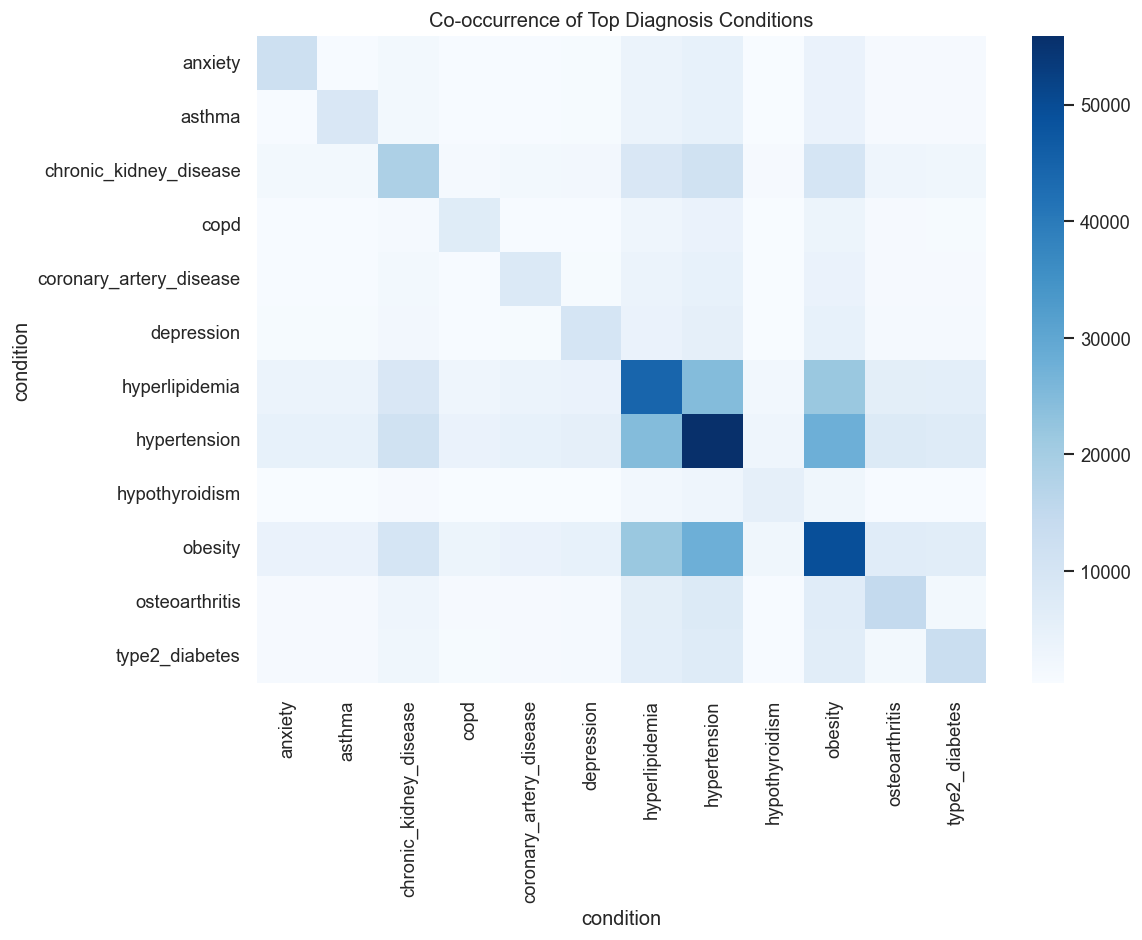

In [5]:
top_conditions = condition_prevalence.head(12).index.tolist()
patient_condition = pd.crosstab(
    condition_events[condition_events["condition"].isin(top_conditions)]["patient_id"],
    condition_events[condition_events["condition"].isin(top_conditions)]["condition"],
)
patient_condition = (patient_condition > 0).astype(int)
co_occurrence = patient_condition.T.dot(patient_condition)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(co_occurrence, cmap="Blues", ax=ax)
ax.set_title("Co-occurrence of Top Diagnosis Conditions")
fig.tight_layout()
save_fig(fig, "04_condition_cooccurrence_heatmap.png")
co_occurrence

PosixPath('/Users/chinmaynaringrekar/PythonProject/Disease Progression and Multimorbidity Prediction/outputs/figures/04_condition_trajectories_by_year.png')

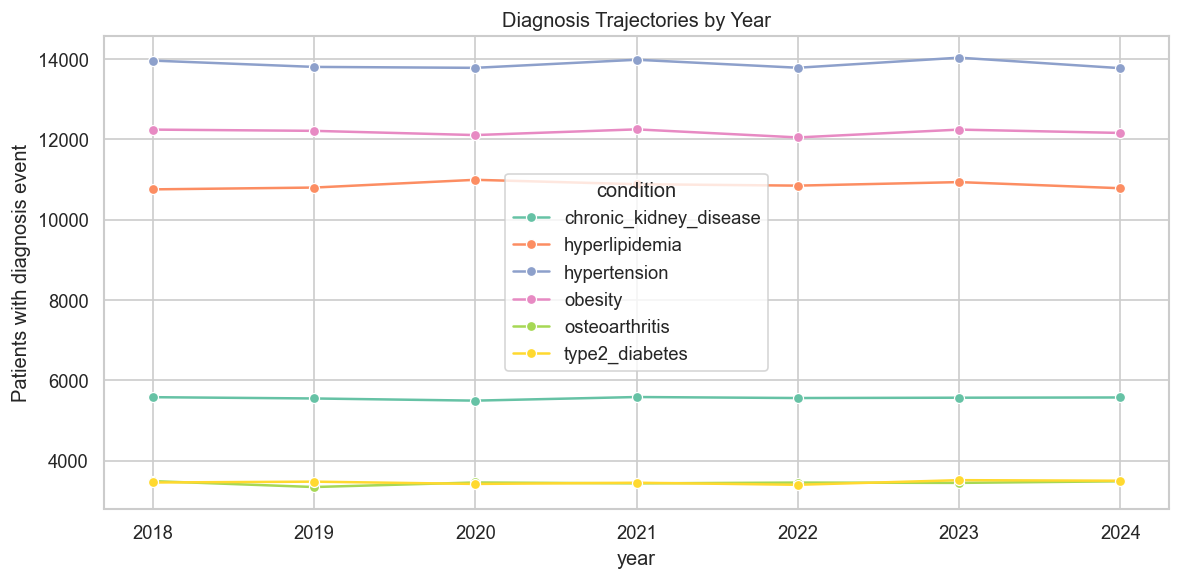

In [6]:
yearly_conditions = (
    condition_events.groupby(["year", "condition"])["patient_id"].nunique().reset_index(name="patients")
)
plot_df = yearly_conditions[yearly_conditions["condition"].isin(top_conditions[:6])]

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=plot_df, x="year", y="patients", hue="condition", marker="o", ax=ax)
ax.set_title("Diagnosis Trajectories by Year")
ax.set_ylabel("Patients with diagnosis event")
fig.tight_layout()
save_fig(fig, "04_condition_trajectories_by_year.png")

## Key findings

- The most common diseases form the core multimorbidity patterns used in later feature engineering.
- Co-occurrence plots identify condition pairs that frequently appear in the same patient histories.
- Yearly diagnosis trajectories help frame disease progression as a time-aware prediction problem.

## Saved outputs

In [7]:
condition_prevalence.to_csv(TABLES_DIR / "04_condition_prevalence.csv")
co_occurrence.to_csv(TABLES_DIR / "04_condition_cooccurrence.csv")
print("Saved multimorbidity tables and figures.")

Saved multimorbidity tables and figures.
